In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tabulate import tabulate
import seaborn as sns

## Independent Variables

In [2]:


# 讀取原始資料
file = 'tej_financialdata_20140101-20241231.xlsx'
df = pd.read_excel(file)

# 轉換數值型態
value_cols = ['流動資產', '流動負債', '資產總額', '  保留盈餘', '來自營運之現金流量', '負債總額']
for col in value_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 計算財務比率
working_capital_total_assets = (df['流動資產'] - df['流動負債']) / df['資產總額']
retained_earnings_total_assets = df['  保留盈餘'] / df['資產總額']
cashflow_total_debt = df['來自營運之現金流量'] / df['負債總額']
total_debt_total_assets = df['負債總額'] / df['資產總額']
current_ratio = df['流動資產'] / df['流動負債']

# 建立新 DataFrame
ratios_df = pd.DataFrame({
    '公司': df['公司'],
    '年/月': df['年/月'],
    'WorkingCapital_TotalAssets': working_capital_total_assets,
    'RetainedEarnings_TotalAssets': retained_earnings_total_assets,
    'CashFlow_TotalDebt': cashflow_total_debt,
    'TotalDebt_TotalAssets': total_debt_total_assets,
    'CurrentRatio': current_ratio
})

# 檢查結果
print(ratios_df.head())
ratios_df.to_excel('ratios.xlsx', index=False)

        公司      年/月  WorkingCapital_TotalAssets  RetainedEarnings_TotalAssets  \
0  1101 台泥  2024/12                    0.146621                      0.122633   
1  1101 台泥  2020/06                    0.102824                      0.155888   
2  1101 台泥  2021/06                    0.161413                      0.221727   
3  1101 台泥  2018/12                    0.133330                      0.178993   
4  1101 台泥  2018/06                    0.114156                      0.155965   

   CashFlow_TotalDebt  TotalDebt_TotalAssets  CurrentRatio  
0            0.111360               0.481124      2.007338  
1            0.098034               0.489048      1.461879  
2            0.078609               0.405556      1.877726  
3            0.150987               0.426364      1.711227  
4            0.072544               0.463646      1.537869  


In [3]:
ratios=ratios_df[['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 'CashFlow_TotalDebt', 'TotalDebt_TotalAssets', 'CurrentRatio']]
def profiling():
  col = ['mean', 'std', 'min', '50%', 'max']
  summary = ratios.describe()
  na = pd.DataFrame(ratios.isnull().sum()/len(ratios)*100,columns = ['NA(%)']).T #計算缺失率
  skew = pd.DataFrame(ratios.skew(),columns=["skewness"]).T #偏度
  kurt = pd.DataFrame(ratios.kurtosis(),columns=["kurtosis"]).T #峰度
  print(tabulate(pd.concat([na, summary.loc[col], skew, kurt]), headers=ratios.columns))
profiling()

            WorkingCapital_TotalAssets    RetainedEarnings_TotalAssets    CashFlow_TotalDebt    TotalDebt_TotalAssets    CurrentRatio
--------  ----------------------------  ------------------------------  --------------------  -----------------------  --------------
NA(%)                        3.13318                          0                    0.0964763               0                3.13318
mean                         0.260084                         0.111762             0.109787                0.457993         3.04299
std                          0.205335                         1.27573              0.49632                 0.195864        11.1524
min                         -0.742243                       -82.0719             -18.1768                  0.00303337       0.0588412
50%                          0.251428                         0.150736             0.080471                0.454693         1.79589
max                          0.996967                         1.58174  

In [4]:
median=ratios_df.describe().loc['50%']
print(median)

WorkingCapital_TotalAssets      0.251428
RetainedEarnings_TotalAssets    0.150736
CashFlow_TotalDebt              0.080471
TotalDebt_TotalAssets           0.454693
CurrentRatio                    1.795890
Name: 50%, dtype: float64


In [5]:
print(ratios_df[ratios_df.isnull().any(axis=1)])


                   公司      年/月  WorkingCapital_TotalAssets  \
10067         2801 彰銀  2014/12                         NaN   
10068         2801 彰銀  2023/06                         NaN   
10069         2801 彰銀  2018/12                         NaN   
10070         2801 彰銀  2017/06                         NaN   
10071         2801 彰銀  2015/12                         NaN   
...               ...      ...                         ...   
19413       6936 永鴻生技  2018/12                    0.209544   
19425         6937 天虹  2019/12                    0.153294   
19485    7722 LINEPAY  2019/12                    0.541482   
19499       7732 金興精密  2019/12                   -0.101725   
20870  911868 同方友友-DR  2014/12                    0.461994   

       RetainedEarnings_TotalAssets  CashFlow_TotalDebt  \
10067                      0.021899            0.001652   
10068                      0.024430           -0.018913   
10069                      0.026550           -0.001795   
10070              

In [6]:
import numpy as np
import pandas as pd

# 1️⃣ 依公司代號前兩碼分群
ratios_df['stock_prefix'] = ratios_df['公司'].astype(str).str[:2]

# 2️⃣ 建立缺值指標欄位（在 groupby 之前）
cols = ['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 
        'CashFlow_TotalDebt', 'TotalDebt_TotalAssets', 'CurrentRatio']

for col in cols:
    ratios_df[f'{col}_miss'] = ratios_df[col].isna().astype(int)

# 3️⃣ 補值函式
def fill_with_group_median(group):
    for col in cols:
        group_median = group[col].median()
        if pd.isna(group_median):
            group_median = median[col]  # median 需事先定義或全體取 median
        group[col] = group[col].fillna(group_median)
    return group

# 4️⃣ 依群組補值
ratios_filled_df = ratios_df.groupby('stock_prefix', group_keys=False).apply(fill_with_group_median)

# 5️⃣ 踢除極端值與取 log（注意順序：先踢再 log）
for col in cols:
    mean = ratios_filled_df[col].mean()
    std = ratios_filled_df[col].std()
    ratios_filled_df = ratios_filled_df[
        (ratios_filled_df[col] >= mean - 3*std) & 
        (ratios_filled_df[col] <= mean + 3*std)
    ]
    ratios_filled_df[col] = np.sign(ratios_filled_df[col]) * np.log1p(np.abs(ratios_filled_df[col]))

# 6️⃣ 檢查結果
print(ratios_filled_df[['公司', '年/月'] + cols + [f'{c}_miss' for c in cols]].head())

# 7️⃣ 輸出
ratios_filled_df.to_excel('ratios_filled.xlsx', index=False)


        公司      年/月  WorkingCapital_TotalAssets  RetainedEarnings_TotalAssets  \
0  1101 台泥  2024/12                    0.136820                      0.115677   
1  1101 台泥  2020/06                    0.097874                      0.144869   
2  1101 台泥  2021/06                    0.149637                      0.200266   
3  1101 台泥  2018/12                    0.125160                      0.164661   
4  1101 台泥  2018/06                    0.108097                      0.144936   

   CashFlow_TotalDebt  TotalDebt_TotalAssets  CurrentRatio  \
0            0.105585               0.392801      1.101055   
1            0.093521               0.398137      0.900925   
2            0.075672               0.340433      1.057000   
3            0.140620               0.355129      0.997401   
4            0.070034               0.380931      0.931325   

   WorkingCapital_TotalAssets_miss  RetainedEarnings_TotalAssets_miss  \
0                                0                                 

In [7]:
ratios=ratios_filled_df[['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 'CashFlow_TotalDebt', 'TotalDebt_TotalAssets', 'CurrentRatio']]
def profiling():
  col = ['mean', 'std', 'min', '50%', 'max']
  summary = ratios.describe()
  na = pd.DataFrame(ratios.isnull().sum()/len(ratios)*100,columns = ['NA(%)']).T #計算缺失率
  skew = pd.DataFrame(ratios.skew(),columns=["skewness"]).T #偏度
  kurt = pd.DataFrame(ratios.kurtosis(),columns=["kurtosis"]).T #峰度
  print(tabulate(pd.concat([na, summary.loc[col], skew, kurt]), headers=ratios.columns))
profiling()

            WorkingCapital_TotalAssets    RetainedEarnings_TotalAssets    CashFlow_TotalDebt    TotalDebt_TotalAssets    CurrentRatio
--------  ----------------------------  ------------------------------  --------------------  -----------------------  --------------
NA(%)                        0                                0                    0                        0               0
mean                         0.215023                         0.135149             0.103381                 0.373306        1.08464
std                          0.15288                          0.167935             0.186678                 0.129052        0.380631
min                         -0.298188                        -1.53474             -0.78052                  0.0258126       0.0741276
50%                          0.215281                         0.141115             0.0783935                0.378056        1.00802
max                          0.623079                         0.948465     

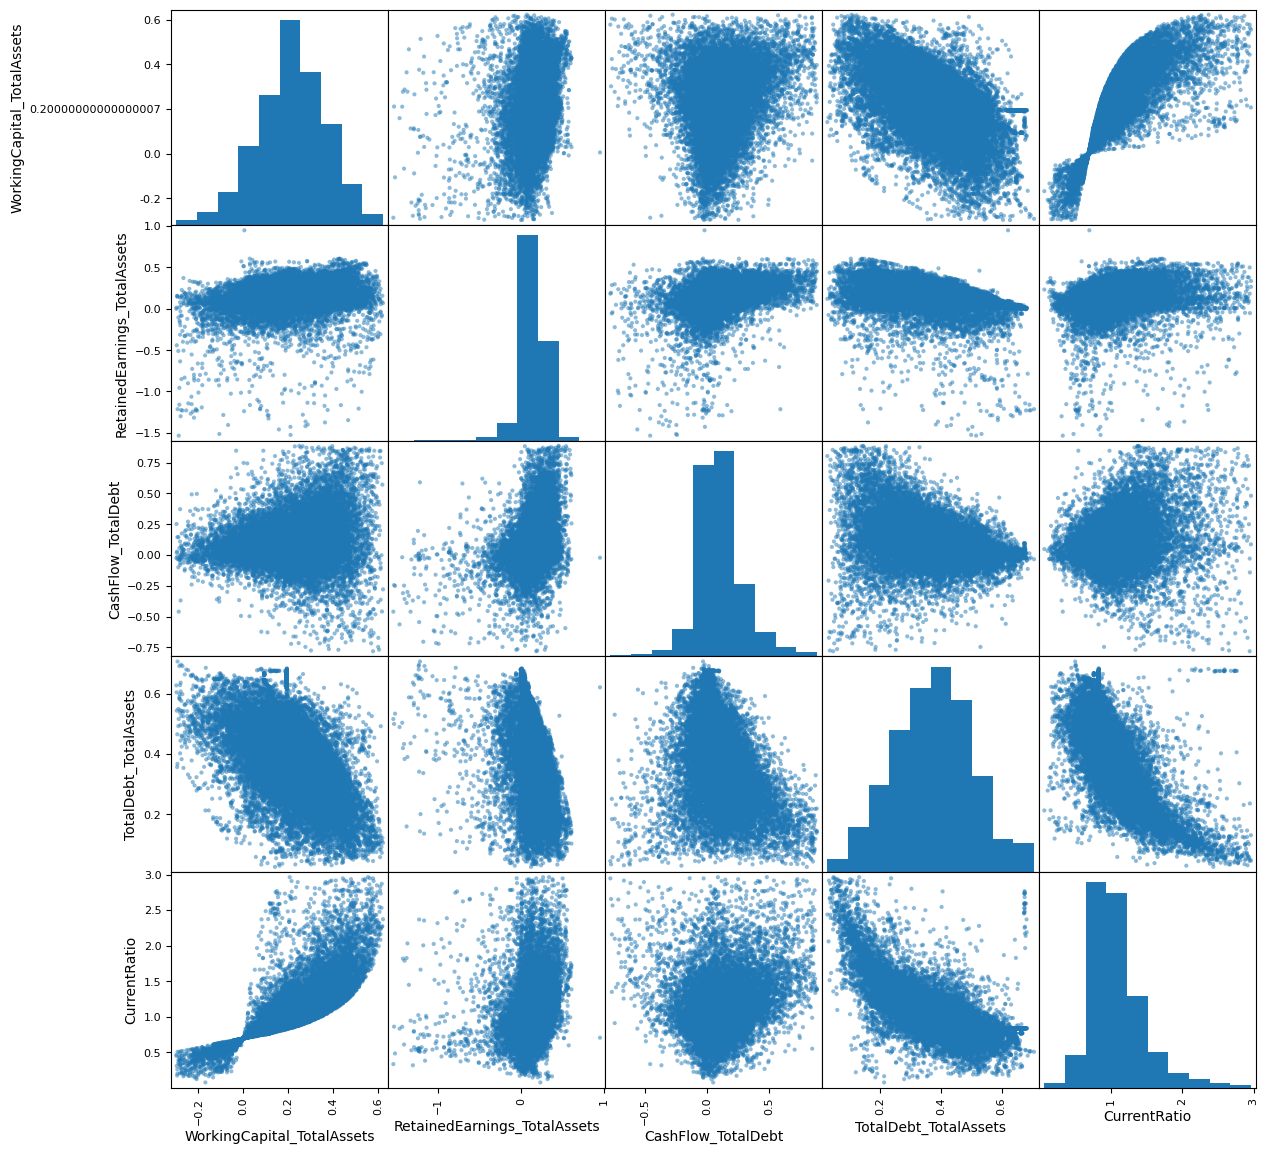

In [8]:
axes=pd.plotting.scatter_matrix(ratios_filled_df[['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 'CashFlow_TotalDebt', 
                                             'TotalDebt_TotalAssets', 'CurrentRatio']],figsize=(14, 14))
# for ax in axes.flatten():
#     ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
#     ax.xaxis.set_major_formatter(mticker.FormatStrFormatter('%.2f'))
plt.savefig('scatter_matrix.png', transparent=True)


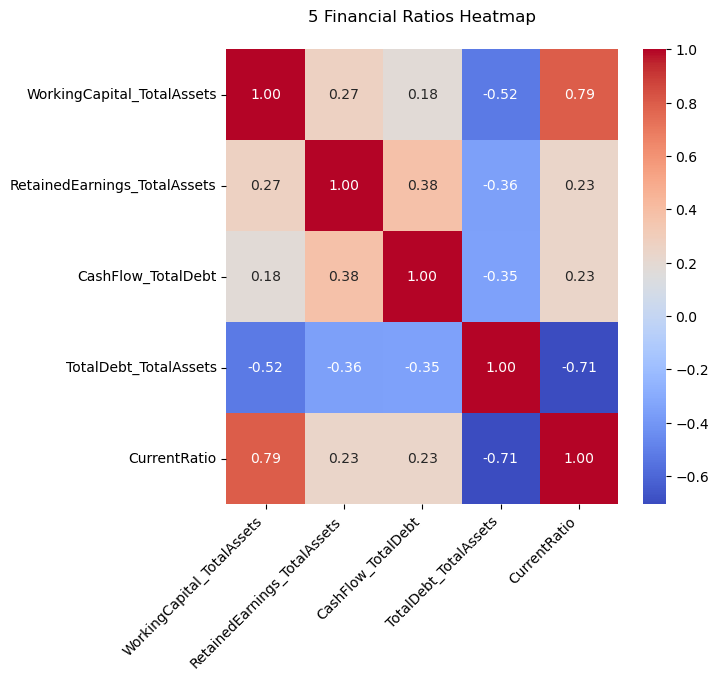

In [9]:

# 選取五個財務比率
cols = ['WorkingCapital_TotalAssets', 'RetainedEarnings_TotalAssets', 'CashFlow_TotalDebt', 'TotalDebt_TotalAssets', 'CurrentRatio']

# 計算相關係數矩陣
corr = ratios_filled_df[cols].corr()

plt.figure(figsize=(7, 7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm')
plt.title('5 Financial Ratios Heatmap', pad=20)  # pad 增加標題與圖的距離

# 旋轉 X 軸文字，避免重疊或被吃掉
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

# 🔧 關鍵：手動調整邊界
plt.subplots_adjust(left=0.25, right=0.95, top=0.9, bottom=0.25)

plt.savefig('heatmap.png', transparent=True, bbox_inches='tight')



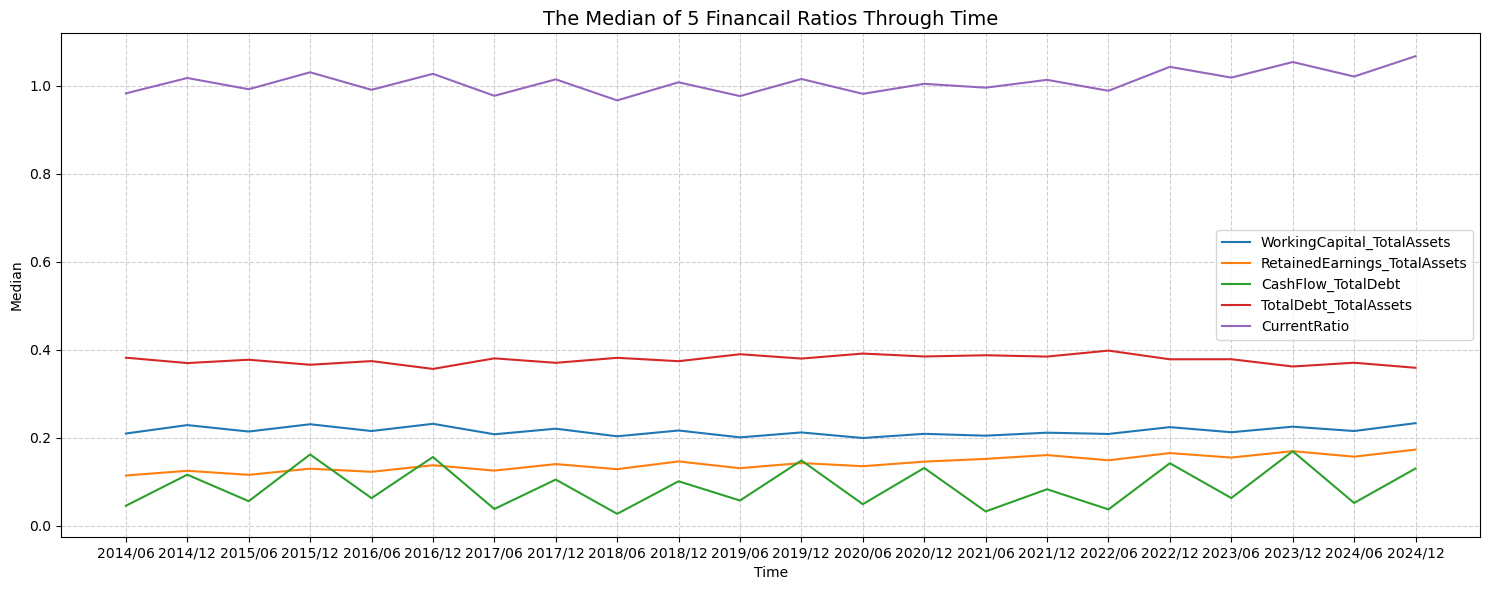

<Figure size 640x480 with 0 Axes>

In [25]:
median_df = ratios_filled_df.groupby('年/月')[cols].median().reset_index()

# 5. 畫折線圖
plt.figure(figsize=(15, 6))
for col in cols:
    plt.plot(median_df['年/月'], median_df[col], label=col)

plt.title("The Median of 5 Financail Ratios Through Time", fontsize=14)
plt.xlabel("Time")
plt.ylabel("Median")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
plt.savefig('LineChart.png', transparent=True, bbox_inches='tight')


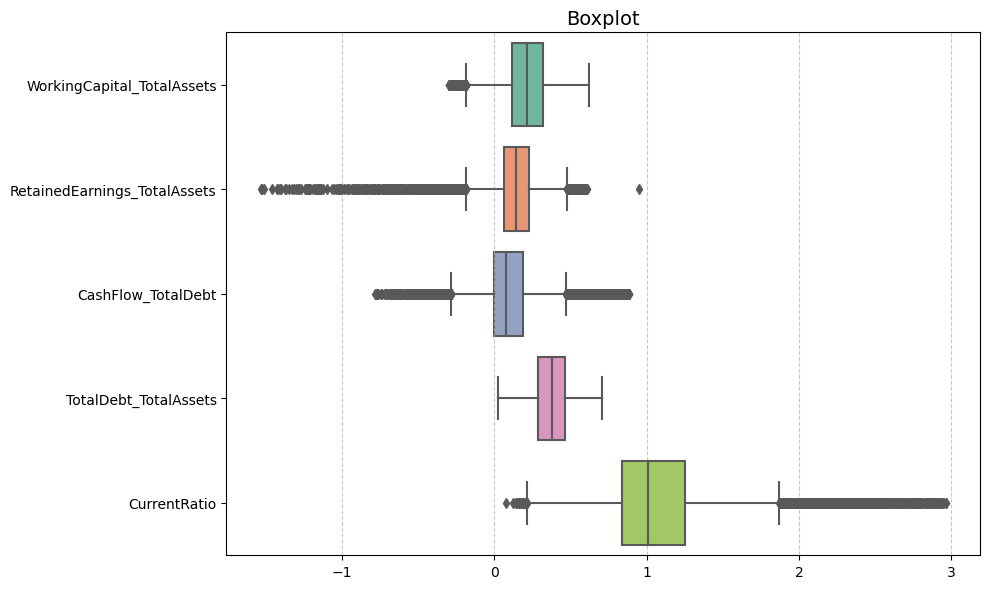

In [35]:
plt.figure(figsize=(10,6))
sns.boxplot(data=ratios_filled_df[cols], orient='h', palette='Set2')
plt.title('Boxplot', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()  # 自動調整邊界
plt.savefig('boxplot.png', bbox_inches='tight',transparent=True)
plt.show()


各主成分的解釋變異比例：
PC1: 53.73%
PC2: 21.71%
PC3: 12.61%
PC4: 8.91%
PC5: 3.04%
前兩個主成分累積解釋變異：75.44%


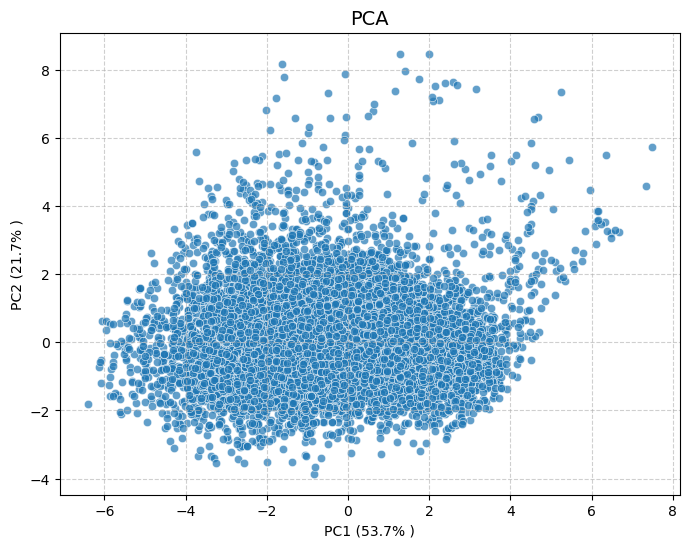

In [33]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
# Step 2.1 標準化資料（PCA前必做，避免尺度差異）
X = ratios_filled_df[cols].dropna()
X_scaled = StandardScaler().fit_transform(X)

# Step 2.2 做 PCA
pca = PCA(n_components=5)
pca_result = pca.fit_transform(X_scaled)

# Step 2.3 建立 PCA 結果 DataFrame
pca_df = pd.DataFrame(
    pca_result,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

# Step 2.4 看主成分解釋的變異比例
explained = pca.explained_variance_ratio_
print("各主成分的解釋變異比例：")
for i, v in enumerate(explained, start=1):
    print(f"PC{i}: {v:.2%}")
print(f"前兩個主成分累積解釋變異：{explained[:2].sum():.2%}")

#Step 3 畫出結果
plt.figure(figsize=(8,6))
sns.scatterplot(x=pca_df['PC1'], y=pca_df['PC2'], alpha=0.7)
plt.title('PCA', fontsize=14)
plt.xlabel(f"PC1 ({explained[0]*100:.1f}% )")
plt.ylabel(f"PC2 ({explained[1]*100:.1f}% )")
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('PCA.png', transparent=True)
plt.show()


## Dependent Variable

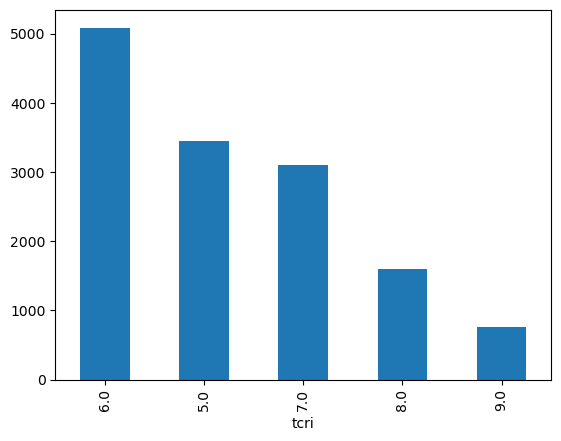

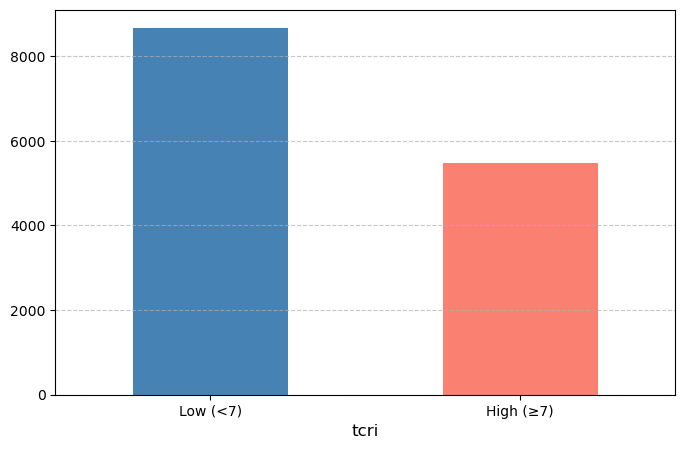

In [34]:
file = 'tcri.csv'
tcri_df = pd.read_csv(file)
tcri_df['tcri'] = pd.to_numeric(tcri_df['tcri'], errors='coerce')
tcri_df['tcri'].value_counts().plot(kind='bar')

# 分組
tcri_df['RatingGroup'] = tcri_df['tcri'].apply(lambda x: 'High (≥7)' if x >= 7 else 'Low (<7)')
plt.savefig('y_histogram.png', transparent=True, bbox_inches='tight')

# Step 2. 畫出兩組的直方圖
plt.figure(figsize=(8,5))
tcri_df['RatingGroup'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'])
plt.xlabel('tcri', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.savefig('2classs_histogram.png', transparent=True)
plt.show()


# 分產業

根據GICS行業分類分為以下11大產業部門
| 虛擬變數|GICS 行業部門|對應台灣產業別|
|----------|----------|----------|
| 1|資訊科技 (IT)|半導體業、 電腦及週邊設備業、 電子零組件業、 光電業、 通信網路業、 電子通路業、 資訊服務業、 其他電子業、 資訊服務|
| 2|金融 (Financials)|銀行業、 證券業、 保險業、 金融控股業 |
|3|醫療保健 (Health Care)|生技醫療業、 生技醫療|
|4|通訊服務 (Comm. Services)|文化創意業、 文化創意|
|5|非核心消費 (Cons. Discret.)|觀光事業、 運動休閒、 汽車工業、 居家生活、 觀光|
|6|核心消費 (Cons. Staples)|食品工業、 貿易百貨、 紡織纖維、 食品、 百貨|
|7|能源 (Energy)|油電燃氣業、 油電燃氣|
|8|工業 (Industrials)|鋼鐵工業、 航運業、 電機機械、 電子商務、 航運、 鋼鐵|
|9|原物料 (Materials)|水泥工業、 玻璃陶瓷、 橡膠工業、 塑膠工業、 化學工業、 化學|
|10|不動產 (Real Estate)|建材營造、 不動產|
|11|公用事業 (Utilities)|綠能環保、 綠能|

公司產業別對應：<br>
https://isin.twse.com.tw/isin/class_main.jsp?market=1&issuetype=1


In [20]:
import pandas as pd
import re

# 1. 讀取資料
try:
    ratios_df = pd.read_excel("ratios_filled.xlsx")
    sector_df = pd.read_excel("industrysector.xlsx")
except UnicodeDecodeError:
    # 嘗試使用繁體中文常用的 Big5 編碼
    ratios_df = pd.read_excel("ratios_filled.xlsx", encoding='big5')
    sector_df = pd.read_excel("industrysector.xlsx", encoding='big5')


# 2. 建立 GICS 映射 (示範性對照表，用於虛擬變數 1-11)
gics_mapping = {
    # 1. 資訊科技 (IT)
    '半導體業': 1, '電腦及週邊設備業': 1, '電子零組件業': 1, '光電業': 1,
    '通信網路業': 1, '電子通路業': 1, '資訊服務業': 1, '其他電子業': 1, '資訊服務': 1,
    # 2. 金融 (Financials)
    '銀行業': 2, '證券業': 2, '保險業': 2, '金融控股業': 2,
    # 3. 醫療保健 (Health Care)
    '生技醫療業': 3, '生技醫療': 3,
    # 4. 通訊服務 (Communication Services)
    '文化創意業': 4, '文化創意': 4,
    # 5. 非核心消費 (Consumer Discretionary)
    '觀光事業': 5, '運動休閒': 5, '汽車工業': 5, '居家生活': 5, '觀光': 5,
    # 6. 核心消費 (Consumer Staples)
    '食品工業': 6, '貿易百貨': 6, '紡織纖維': 6, '食品': 6, '百貨': 6,
    # 7. 能源 (Energy)
    '油電燃氣業': 7, '油電燃氣': 7,
    # 8. 工業 (Industrials)
    '鋼鐵工業': 8, '航運業': 8, '電機機械': 8, '電子商務': 8, '航運': 8, '鋼鐵': 8,
    # 9. 原物料 (Materials)
    '水泥工業': 9, '玻璃陶瓷': 9, '橡膠工業': 9, '塑膠工業': 9, '化學工業': 9, '化學': 9,
    # 10. 不動產 (Real Estate)
    '建材營造業': 10, '不動產': 10,
    # 11. 公用事業 (Utilities)
    '綠能環保': 11, '綠能': 11,
    # 0. 其他/未分類
    '其他業': 0, '其他': 0, '綜合': 0
}

# --- 3. 處理 industrysector (關鍵修正點) ---

# 3.1. 提取國際證券編碼的第 6 到第 9 碼作為合併代號
def extract_code_from_isin(isin_code):
    isin_code = str(isin_code).strip()
    # 檢查長度是否足夠，通常是 TW000 + 代碼 + 0004/等，總長12
    if len(isin_code) >= 9:
        # 索引從 0 開始，所以第 6 到第 9 碼是 [5:9]
        return isin_code[5:9]
    return None

sector_df['Merge_Code'] = sector_df['國際證券編碼'].apply(extract_code_from_isin).astype(str).str.strip()

# 3.2. 新增 GICS_Category 虛擬變數欄位
sector_df['GICS_Category'] = sector_df['產業別'].map(gics_mapping).fillna(0).astype(int)

# 篩選出用於合併的欄位
sector_info = sector_df[['Merge_Code', '產業別', 'GICS_Category']].copy()

print("\n--- industrysector 合併代號範例 ---")
print(sector_info.head(5))


# --- 4. 處理 ratios_filled ---

# 4.1. 從公司欄位提取股票代號 (處理 "股票代碼 公司名稱" 格式)
def extract_stock_code(company_name):
    # 使用正則表達式尋找開頭的數字。這也是我們需要的 4 碼代號。
    match = re.match(r'^(\d{4,6})', str(company_name).strip()) # 允許4-6位數字代碼
    if match:
        return match.group(1)
    return None

# 將提取的代號命名為 Merge_Code，以便與 sector_info 合併
ratios_df['Merge_Code'] = ratios_df['公司'].apply(extract_stock_code).astype(str).str.strip()


# --- 5. 合併資料 ---

merged_df = pd.merge(
    ratios_df,
    sector_info,
    on='Merge_Code', # 使用修正後的 Merge_Code 進行合併
    how='left' 
)
# 確保初步的 GICS_Category (由合併產生) 設為 0
merged_df['GICS_Category'] = merged_df['GICS_Category'].fillna(0).astype(int)


# --- 6. 填補缺失值 ---


# 6.1. 創建分組鍵：股票代碼前兩碼
merged_df['Prefix_Code'] = merged_df['Merge_Code'].str[:2]

# 6.2. 定義填補函數：用組內的眾數 (Mode) 或第一個非空值來填補
def fill_na_by_group(series):
    # 找到組內出現次數最多的 '產業別'
    mode_val = series.mode()
    if not mode_val.empty:
        return series.fillna(mode_val.iloc[0])
    return series.fillna('未分類') # 如果整組都是缺失值，則填補 '未分類'

# 6.3. 執行分組填補
merged_df['產業別_Filled'] = merged_df.groupby('Prefix_Code')['產業別'].transform(fill_na_by_group)

# 6.4. 將合併後仍缺失的 '產業別' 欄位更新為填補後的結果
# 只有原本缺失的 '產業別' 會被更新，如果 '產業別' 仍為空 (因整組都是空值)，則設為 '未分類'
merged_df['產業別'] = merged_df['產業別_Filled']
merged_df['產業別'] = merged_df['產業別'].fillna('未分類')


# --- 7. 重新計算 GICS 虛擬變數 ---

# 7.1. 根據新的 '產業別' 欄位，重新應用 GICS 映射
# 注意：新增 '未分類' 到映射表
final_gics_mapping = gics_mapping.copy()
final_gics_mapping['未分類'] = 0 

merged_df['GICS_Category_Final'] = merged_df['產業別'].map(final_gics_mapping).fillna(0).astype(int)

# 移除中介欄位
merged_df = merged_df.drop(columns=['Prefix_Code', '產業別_Filled', 'GICS_Category']) 
merged_df = merged_df.rename(columns={'GICS_Category_Final': 'GICS_Category'})


print("\n--- 填補後結果範例 ---")
# 顯示包含新欄位的資料
print(merged_df[['公司', 'Merge_Code', '產業別', 'GICS_Category']].head())

print("\n--- 填補後 GICS 分類統計 ---")
print(merged_df['GICS_Category'].value_counts().sort_index())

# 將結果儲存到新的 CSV 檔案
output_filename = 'ratios_filled_with_gics_category.csv'
merged_df.to_csv(output_filename, index=False, encoding='utf-8-sig')


--- industrysector 合併代號範例 ---
  Merge_Code   產業別  GICS_Category
0       1101  水泥工業              9
1       1102  水泥工業              9
2       1103  水泥工業              9
3       1104  水泥工業              9
4       1108  水泥工業              9

--- 填補後結果範例 ---
        公司 Merge_Code   產業別  GICS_Category
0  1101 台泥       1101  水泥工業              9
1  1101 台泥       1101  水泥工業              9
2  1101 台泥       1101  水泥工業              9
3  1101 台泥       1101  水泥工業              9
4  1101 台泥       1101  水泥工業              9

--- 填補後 GICS 分類統計 ---
GICS_Category
0     3238
1     9255
3      737
5     1110
6     1343
7      173
8     2264
9     1564
10    1171
11     438
Name: count, dtype: int64

✨ 最終結果已儲存為： ratios_filled_with_gics_category.csv


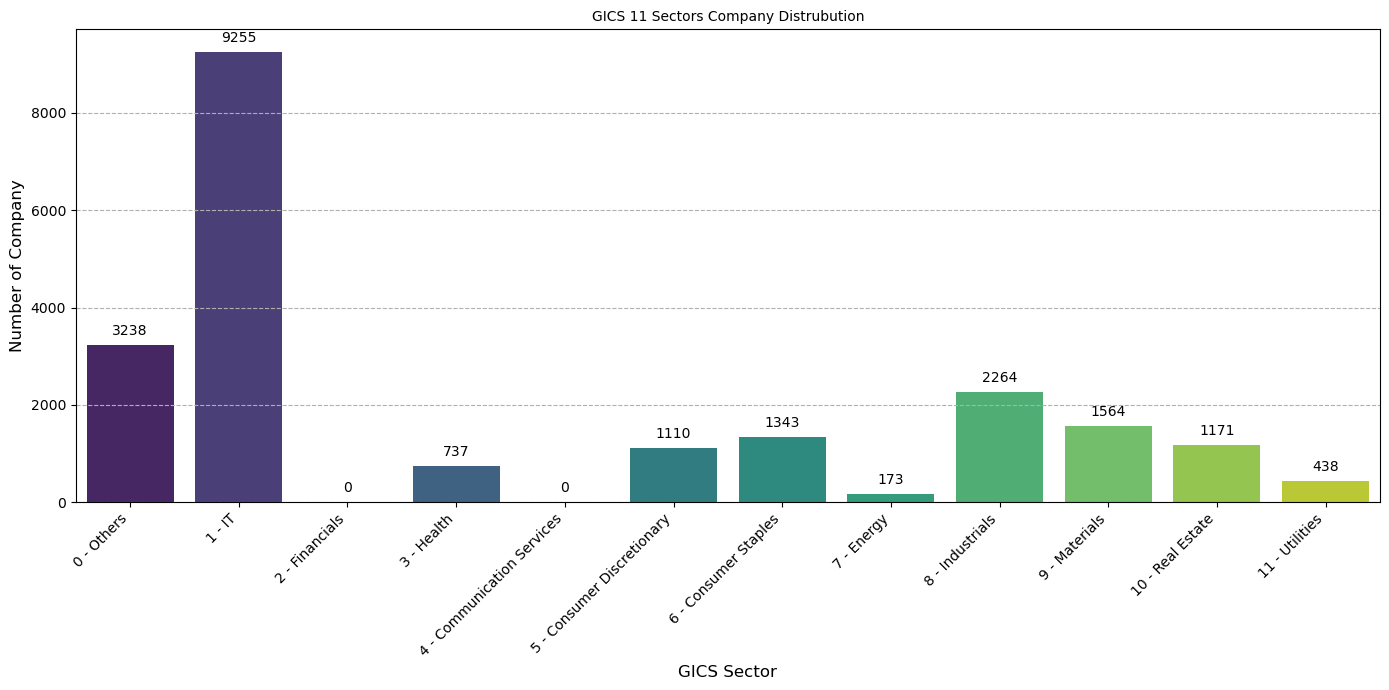

In [30]:
# --- 3. 繪製類別分布圖 ---

# 建立 GICS 代碼到名稱的對照表
gics_labels = {
    0: '0 - Others', 1: '1 - IT', 2: '2 - Financials',
    3: '3 - Health', 4: '4 - Communication Services', 5: '5 - Consumer Discretionary',
    6: '6 - Consumer Staples', 7: '7 - Energy', 8: '8 - Industrials',
    9: '9 - Materials', 10: '10 - Real Estate', 11: '11 - Utilities'
}

# 準備繪圖數據：確保所有類別 (0-11) 都在 X 軸上
full_categories = range(0, 12) 
full_labels = [gics_labels[i] for i in full_categories]
plot_data = merged_df['GICS_Category'].value_counts().reindex(full_categories, fill_value=0)


plt.figure(figsize=(14, 7))
sns.barplot(
    x=plot_data.index, 
    y=plot_data.values,
    order=full_categories,
    palette='viridis'
)

# 設定圖表標題和標籤
plt.title('GICS 11 Sectors Company Distrubution', fontsize=16, fontproperties=font_prop)
plt.xlabel('GICS Sector', fontsize=12, fontproperties=font_prop)
plt.ylabel('Number of Company', fontsize=12, fontproperties=font_prop)

# 設置 X 軸刻度標籤為完整的中文標籤，並旋轉
plt.xticks(
    ticks=full_categories, 
    labels=full_labels,
    rotation=45, 
    ha='right',
    fontproperties=font_prop # 確保刻度標籤也使用正確字體
)

# 增加數據標籤
ax = plt.gca()
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{int(height)}', 
                (p.get_x() + p.get_width() / 2., height), 
                ha='center', va='center', 
                xytext=(0, 10), 
                textcoords='offset points',
                fontproperties=font_prop) # 確保數據標籤也使用正確字體

plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.savefig('Sector_histogram.png', transparent=True)
plt.show()

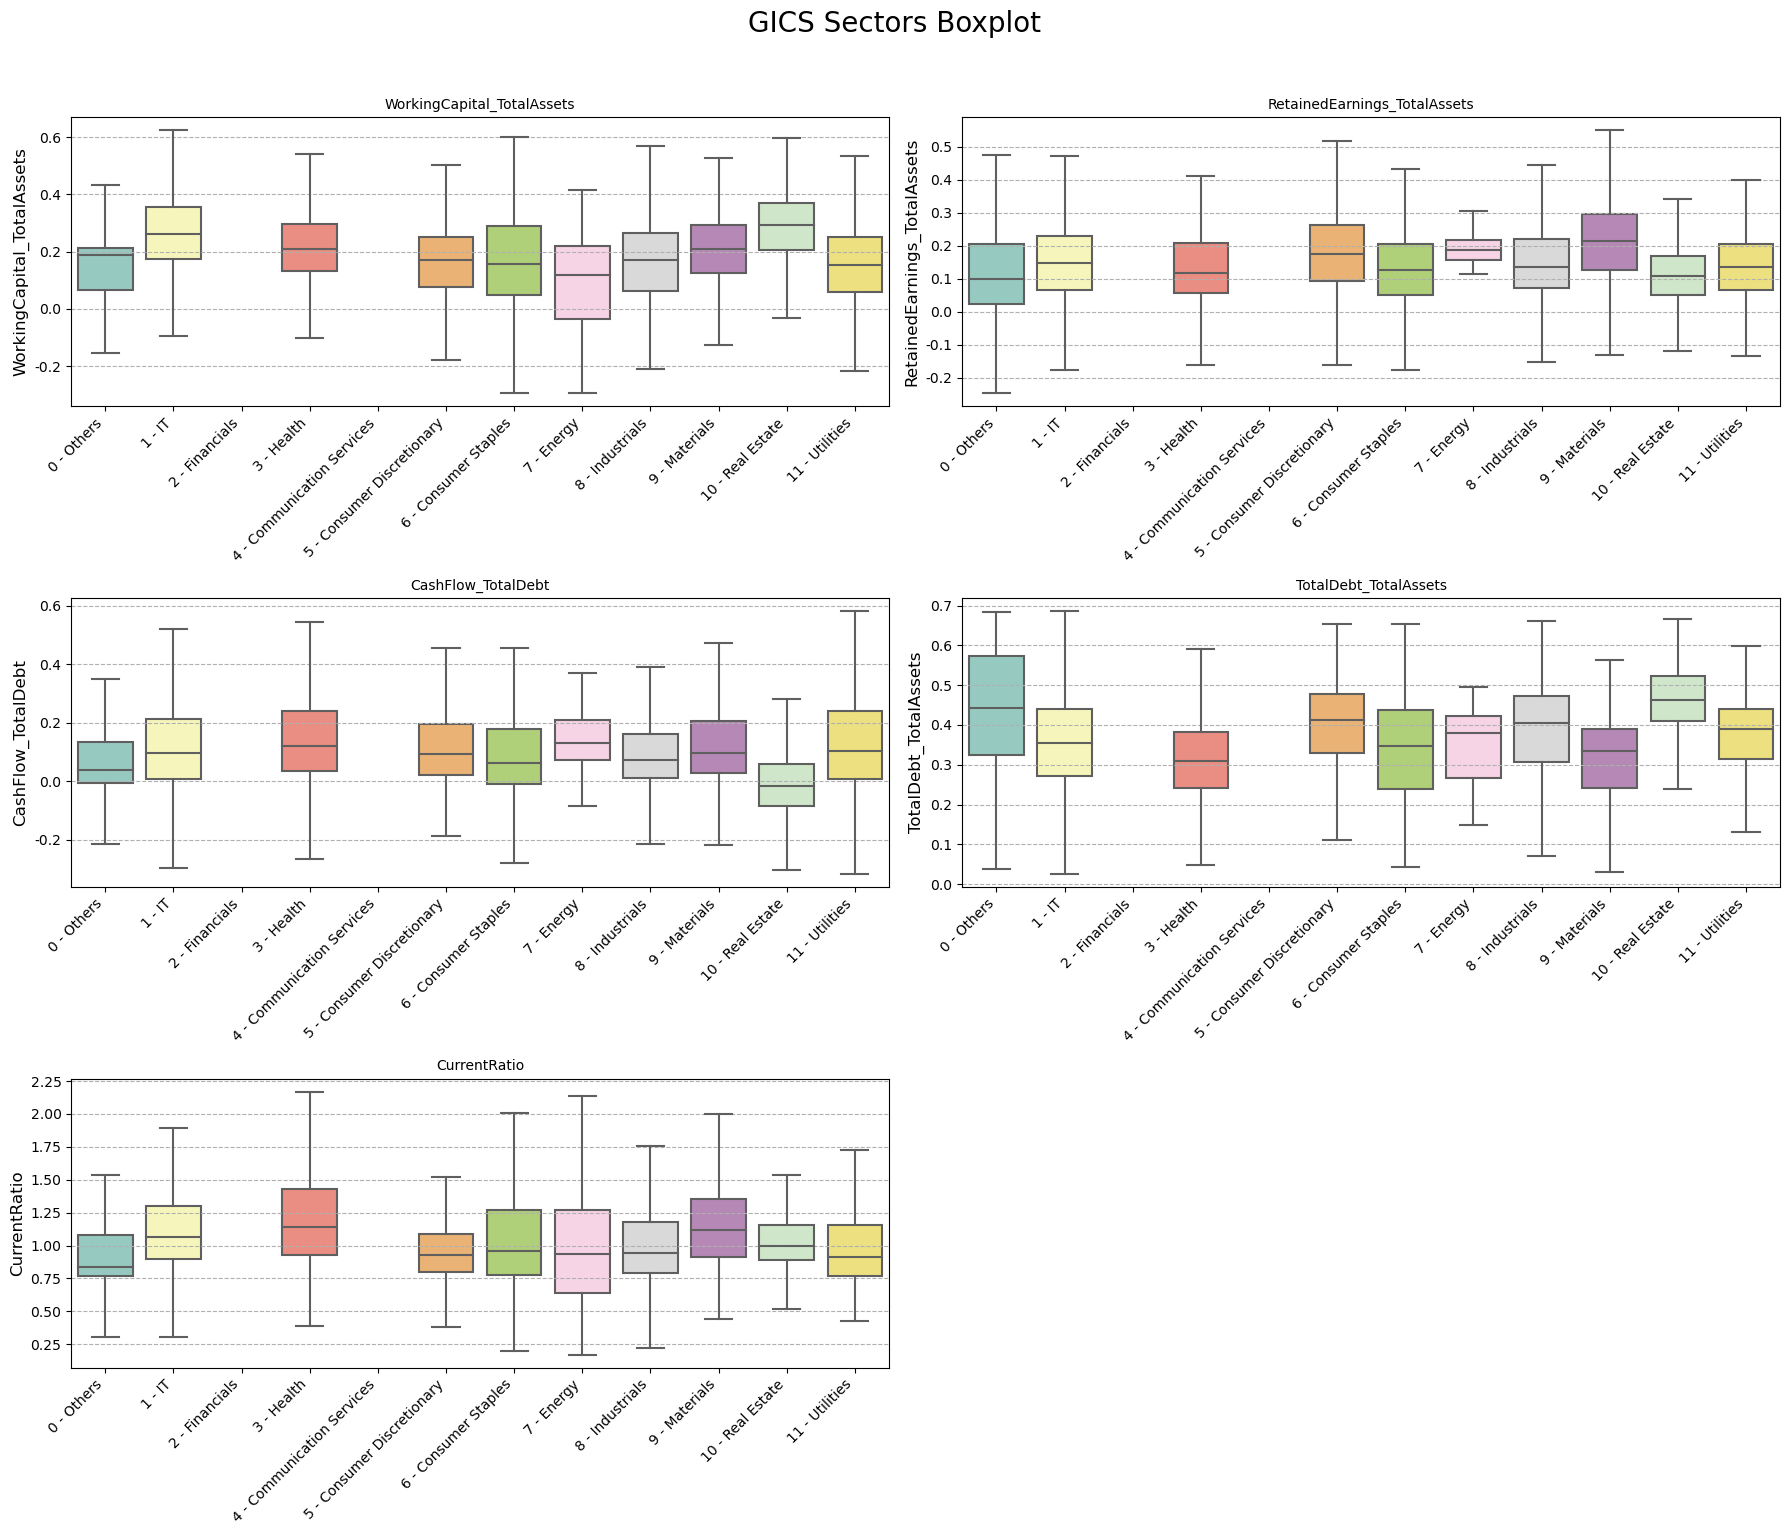

In [39]:
# 定義要繪製的財務比率欄位
financial_ratios = [
    'WorkingCapital_TotalAssets',
    'RetainedEarnings_TotalAssets',
    'CashFlow_TotalDebt',
    'TotalDebt_TotalAssets',
    'CurrentRatio'
]
# 確保 GICS_Category 是分類變數，並映射到中文標籤
merged_df['GICS_Category_Label'] = merged_df['GICS_Category'].map(gics_labels)
# 定義 X 軸的排序 (確保 0-11 順序正確)
category_order = [gics_labels[i] for i in range(0, 12)]


# 創建一個 3x2 的子圖佈局來容納 5 個箱形圖
fig, axes = plt.subplots(3, 2, figsize=(18, 15))
axes = axes.flatten() # 將 3x2 陣列展平為一維陣列，方便迭代

for i, ratio in enumerate(financial_ratios):
    # 使用 seaborn 繪製箱形圖
    sns.boxplot(
        ax=axes[i],
        x='GICS_Category_Label',  # GICS 類別作為 X 軸
        y=ratio,                 # 財務比率作為 Y 軸
        data=merged_df,
        order=category_order,     # 確保 X 軸順序正確 (0-11)
        palette='Set3',           # 使用顏色調色盤
        showfliers=False          # 暫時不顯示極端值(離群值)，使圖表更清晰
    )
    title_prop = {'fontproperties': font_prop} if font_prop else {}
    # 設置標題和標籤
    axes[i].set_title(f'{ratio}', fontsize=14, **title_prop)
    axes[i].set_xlabel('', fontsize=12, **title_prop)
    axes[i].set_ylabel(ratio, fontsize=12)

    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right', fontsize=10, **title_prop)
    
    axes[i].grid(axis='y', linestyle='--')
    
    # 旋轉 X 軸標籤以避免重疊
    axes[i].tick_params(axis='x', rotation=45, labelsize=10)
    
    # 設置 Y 軸網格線
    axes[i].grid(axis='y', linestyle='--')

# 隱藏最後一個空白子圖
axes[5].axis('off')

plt.suptitle('GICS Sectors Boxplot', fontsize=20, fontproperties=font_prop if 'font_prop' in locals() else None, y=1.02)
plt.tight_layout() # 自動調整佈局
plt.show()